# Phase 4 (notebook 04) — prep & audit + feature scaffold + grouped CV

After 02 and 03 we have a sharp picture: A (carry-forward) holds at pooled RMSE 15.91, geometry-based
methods (B, C) lose by 7×, hand-crafted GR correlation (E) loses by 2.4×. Hand-crafted methods can't
encode the right "trust the anchor unless GR really says otherwise" prior. Time to set up an ML path —
but first do the prep work we skipped: properly audit the target, characterize A's failure modes, build
a featurizer with explicit leakage controls, and lay down a grouped-by-well cross-validation scheme.

**Sections:**
- §0 Setup
- §1 Reload caches + helpers (modified GR-match returns similarity for use as a feature)
- §2 Target/label audit — what does TVT actually look like inside eval zones across all 773 wells?
- §3 Error audit on A — what kind of well is A bad on? (Cluster failure modes.)
- §4 Feature engineering scaffold — `featurize_well(g, tw)` with the leakage rule documented
- §5 GroupKFold cross-validation — splits so entire wells are held out (required for honest ML)
- §6 Leakage sanity checks — assertions that no feature depends on eval-zone target
- §7 Featurize test wells + cache everything for notebook 05
- §8 Findings + roadmap

**End state:** `cache/train_features.pkl` and `cache/test_features.pkl` ready for notebook 05
("first XGBoost with proper CV"). The featurizer logic and CV scaffold are reusable.

## 0. Setup

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

ROOT = Path('..').resolve()
DATA = ROOT / 'data'
TRAIN_DIR = DATA / 'train'
TEST_DIR  = DATA / 'test'
CACHE_DIR = ROOT / 'cache';        CACHE_DIR.mkdir(exist_ok=True)

COL_MD, COL_X, COL_Y, COL_Z = 'MD', 'X', 'Y', 'Z'
COL_GR = 'GR'
COL_TVT_INPUT = 'TVT_input'
COL_TVT       = 'TVT'

print(f'Project root: {ROOT}')

Project root: /home/gokhuu/portfolio/ROGII-Wellbore


## 1. Reload caches + helpers

- `train_df` and `train_tw`: cached from 03.
- `evaluate_baseline`, `predict_carry_forward`: same as 03 (we'll need A's per-well RMSE for the §3 audit).
- `predict_gr_match_v2`: modified version that returns *both* per-row predictions *and* per-row cosine
  similarities. The similarity becomes a feature in §4 (signal of how much to trust the GR-match output).

In [2]:
TRAIN_HW_CACHE = CACHE_DIR / 'train_wells.pkl'
TRAIN_TW_CACHE = CACHE_DIR / 'train_typewells.pkl'

train_df = pd.read_pickle(TRAIN_HW_CACHE)
train_tw = pd.read_pickle(TRAIN_TW_CACHE)
print(f'train_df: {train_df.shape}  |  typewells: {len(train_tw)}')

# --- Harness (same as 03) ---
def evaluate_baseline(predict_fn, train_df, typewells, label='', progress=0):
    rows, sse_total, n_total = [], 0.0, 0
    for i, (well, g) in enumerate(train_df.groupby('well', sort=False)):
        if progress and i and i % progress == 0:
            print(f'  ... {i} wells', flush=True)
        eval_mask = g[COL_TVT_INPUT].isna().values
        if not eval_mask.any(): continue
        truth = g.loc[eval_mask, COL_TVT].values
        tw = typewells.get(well)
        pred = np.asarray(predict_fn(g, tw), dtype=float)
        diff = pred[eval_mask] - truth
        sq = diff ** 2
        rows.append({'well': well, 'rmse': float(np.sqrt(sq.mean())),
                     'n_eval': int(eval_mask.sum()),
                     'mae': float(np.abs(diff).mean()),
                     'max_err': float(np.abs(diff).max())})
        sse_total += float(sq.sum()); n_total += int(len(sq))
    res = pd.DataFrame(rows)
    pooled = float(np.sqrt(sse_total / n_total)) if n_total else float('nan')
    if label:
        print(f'{label:30s}  pooled RMSE = {pooled:8.3f}')
    return res, pooled

def predict_carry_forward(g, tw=None):
    return g[COL_TVT_INPUT].ffill().bfill().values.astype(float)

res_A, rmse_A = evaluate_baseline(predict_carry_forward, train_df, train_tw, 'A. carry-forward')

train_df: (5092255, 15)  |  typewells: 773
A. carry-forward                pooled RMSE =   15.910


In [3]:
def predict_gr_match_v2(g: pd.DataFrame, tw: pd.DataFrame,
                        window: int = 51, search_radius: float = 50.0, smooth: int = 11):
    """Returns (pred, similarity) — both arrays of length len(g).
    Similarity is the max cosine sim used to pick each row's prediction (0 for fallback rows)."""
    n = len(g)
    pred = g[COL_TVT_INPUT].values.astype(float).copy()
    sim  = np.zeros(n, dtype=float)
    eval_mask = np.isnan(pred)
    if not eval_mask.any():
        return pred, sim
    known_idx = np.where(~eval_mask)[0]
    if len(known_idx) == 0:
        return pred, sim
    anchor = float(pred[known_idx[-1]])
    eval_idx = np.where(eval_mask)[0]

    lat_gr = pd.Series(g[COL_GR].values).interpolate(limit_direction='both').values.astype(float)
    if not np.isfinite(lat_gr).all():
        pred[eval_mask] = anchor
        return pred, sim
    lat_gr_z = (lat_gr - lat_gr.mean()) / (lat_gr.std() + 1e-9)

    if tw is None or COL_GR not in tw or COL_TVT not in tw:
        pred[eval_mask] = anchor
        return pred, sim
    tw_clean = tw.dropna(subset=[COL_TVT, COL_GR]).drop_duplicates(subset=[COL_TVT]).sort_values(COL_TVT)
    if len(tw_clean) < window + 2:
        pred[eval_mask] = anchor
        return pred, sim
    tvt_grid = np.arange(np.floor(tw_clean[COL_TVT].min()), np.ceil(tw_clean[COL_TVT].max()) + 1, 1.0)
    if len(tvt_grid) < window + 2:
        pred[eval_mask] = anchor
        return pred, sim
    gr_grid = np.interp(tvt_grid, tw_clean[COL_TVT].values, tw_clean[COL_GR].values)
    gr_grid_z = (gr_grid - gr_grid.mean()) / (gr_grid.std() + 1e-9)

    half = window // 2
    n_tw = len(gr_grid_z)
    TW_W = np.lib.stride_tricks.sliding_window_view(gr_grid_z, window).copy()
    norms = np.linalg.norm(TW_W, axis=1, keepdims=True); norms[norms < 1e-9] = 1.0
    TW_W /= norms
    tw_centers = tvt_grid[half : n_tw - half]

    cand_mask = np.abs(tw_centers - anchor) <= search_radius
    if not cand_mask.any():
        pred[eval_mask] = anchor
        return pred, sim

    n_lat = len(lat_gr_z)
    LAT_W_all = np.lib.stride_tricks.sliding_window_view(lat_gr_z, window)
    in_bounds = (eval_idx >= half) & (eval_idx <= n_lat - half - 1)
    pred[eval_idx[~in_bounds]] = anchor
    eval_full = eval_idx[in_bounds]
    if len(eval_full) == 0:
        return pred, sim

    LAT_W = LAT_W_all[eval_full - half].copy()
    lat_norms = np.linalg.norm(LAT_W, axis=1, keepdims=True); lat_norms[lat_norms < 1e-9] = 1.0
    LAT_W /= lat_norms

    S = LAT_W @ TW_W.T
    S_masked = S.copy(); S_masked[:, ~cand_mask] = -np.inf
    best = np.argmax(S_masked, axis=1)
    raw = tw_centers[best]
    raw_sim = S[np.arange(len(eval_full)), best]   # actual cosine sim at the chosen TVT

    if smooth and smooth > 1:
        raw = pd.Series(raw).rolling(smooth, center=True, min_periods=1).median().values

    pred[eval_full] = raw
    sim[eval_full]  = raw_sim
    return pred, sim

# Quick sanity check on one well
_w0 = train_df['well'].iloc[0]
_g0 = train_df[train_df['well'] == _w0]
_tw0 = train_tw[_w0]
_p, _s = predict_gr_match_v2(_g0, _tw0)
print(f'sample well {_w0}: pred shape {_p.shape}, sim shape {_s.shape}, '
      f'sim range on eval rows: [{_s[_s != 0].min():.3f}, {_s[_s != 0].max():.3f}]')

sample well 000d7d20: pred shape (5278,), sim shape (5278,), sim range on eval rows: [0.017, 0.791]


## 2. Target/label audit — what does TVT do in the eval zone?

Compute per-well stats over the *eval-zone TVT trajectory*. The output is a DataFrame `well_stats` with
one row per well joined to A's per-well RMSE. Then we look at distributions and (in §3) at the wells where
A fails worst.

**The big question:** how often does TVT actually move in the eval zone, and by how much? Carry-forward
is correct exactly to the extent that TVT stays near the anchor. If most wells have TVT change <10 over
the whole eval zone, A is unbeatable on those and any model has to win on the rare big-change wells.

In [4]:
def compute_well_stats(g: pd.DataFrame) -> dict | None:
    eval_mask = g[COL_TVT_INPUT].isna().values
    if not eval_mask.any(): return None
    known_idx = np.where(~eval_mask)[0]
    if len(known_idx) == 0: return None
    anchor_tvt = float(g[COL_TVT_INPUT].iloc[known_idx[-1]])
    anchor_z   = float(g[COL_Z].iloc[known_idx[-1]])
    truth = g[COL_TVT].values[eval_mask]
    z_eval = g[COL_Z].values[eval_mask]
    gr_eval = g[COL_GR].values[eval_mask]
    md_eval = g[COL_MD].values[eval_mask]
    diffs = np.diff(truth)
    return {
        'n_eval':                  int(eval_mask.sum()),
        'anchor_tvt':              anchor_tvt,
        'anchor_z':                anchor_z,
        'tvt_change':              float(truth[-1] - truth[0]),
        'tvt_range':               float(truth.max() - truth.min()),
        'tvt_max_abs_dev':         float(np.max(np.abs(truth - anchor_tvt))),
        'tvt_mean_dev':            float(np.mean(truth - anchor_tvt)),
        'tvt_max_step':            float(np.max(np.abs(diffs))) if len(diffs) else 0.0,
        'tvt_monotonic_inc':       bool(np.all(diffs >= -1e-9)) if len(diffs) else True,
        'tvt_monotonic_dec':       bool(np.all(diffs <=  1e-9)) if len(diffs) else True,
        'z_change':                float(z_eval[-1] - z_eval[0]),
        'z_range':                 float(z_eval.max() - z_eval.min()),
        'gr_eval_mean':            float(np.nanmean(gr_eval)),
        'gr_eval_std':             float(np.nanstd(gr_eval)),
        'gr_eval_nan_frac':        float(np.isnan(gr_eval).mean()),
    }

rows = []
for well, g in train_df.groupby('well', sort=False):
    s = compute_well_stats(g)
    if s: s['well'] = well; rows.append(s)
well_stats = pd.DataFrame(rows).set_index('well')

# Join A's per-well RMSE
well_stats = well_stats.join(res_A.set_index('well')[['rmse']].rename(columns={'rmse': 'a_rmse'}))

print(f'Wells with stats: {len(well_stats)}')
well_stats.describe().T[['mean', 'std', '50%', 'max']].round(2)

Wells with stats: 773


,mean,std,50%,max
n_eval,4895.20,1301.18,4840.00,10052.00
anchor_tvt,11551.06,619.90,11368.71,12873.07
anchor_z,-9447.93,611.56,-9284.27,-7952.31
tvt_change,0.98,20.58,1.40,89.21
tvt_range,29.41,14.79,26.37,121.84
tvt_max_abs_dev,23.73,14.10,20.45,103.78
tvt_mean_dev,1.42,12.70,0.94,65.93
tvt_max_step,0.95,1.73,0.11,15.61
z_change,26.06,174.15,100.02,428.76
z_range,165.33,62.18,160.56,428.76


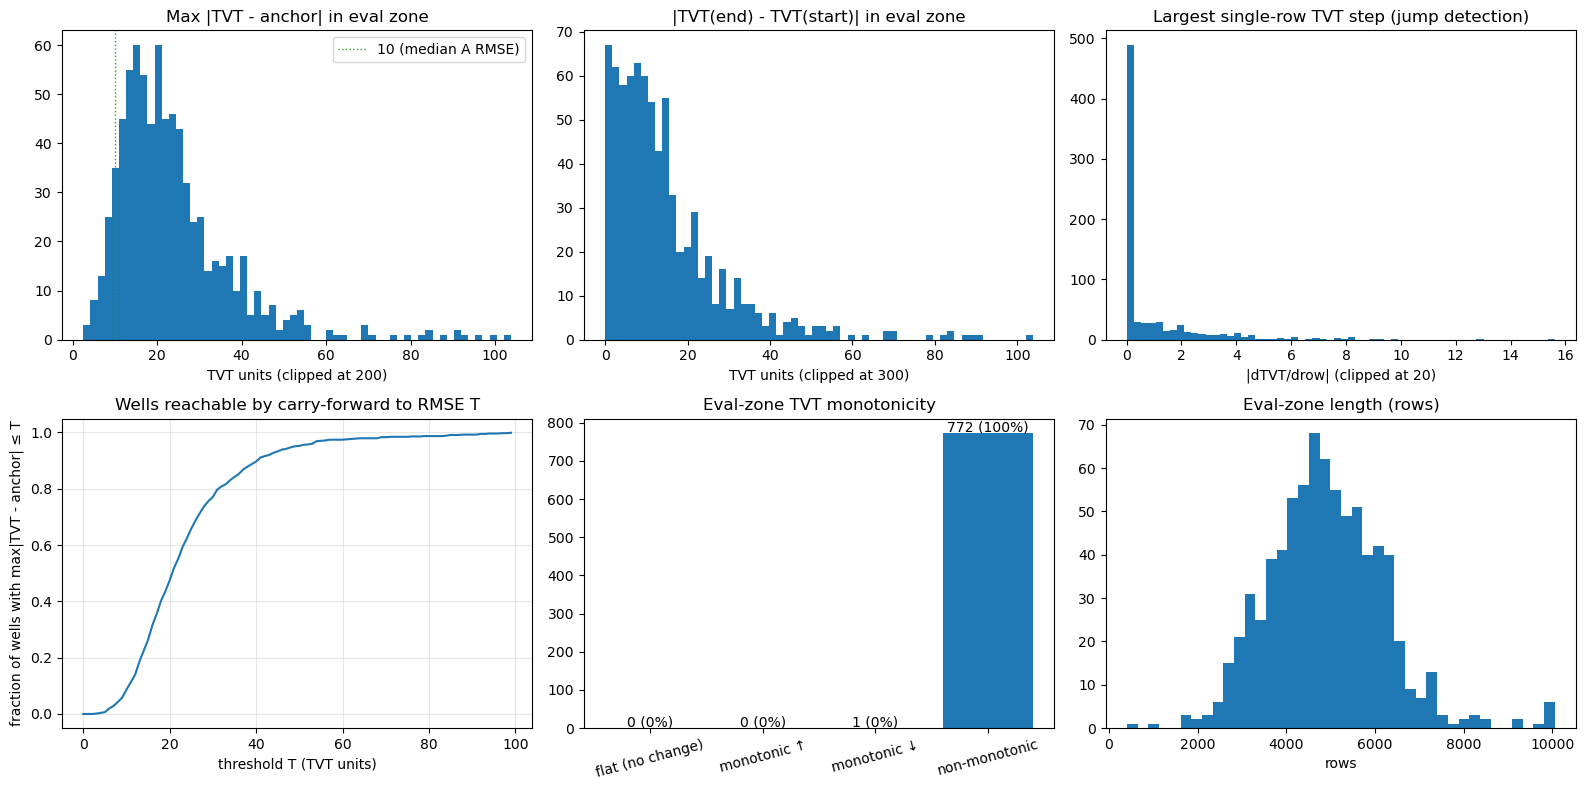

In [5]:
# Headline distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].hist(well_stats['tvt_max_abs_dev'].clip(upper=200), bins=60)
axes[0, 0].set_title('Max |TVT - anchor| in eval zone')
axes[0, 0].set_xlabel('TVT units (clipped at 200)')
axes[0, 0].axvline(10, color='C2', ls=':', lw=1, label='10 (median A RMSE)')
axes[0, 0].legend()

axes[0, 1].hist(np.abs(well_stats['tvt_change']).clip(upper=300), bins=60)
axes[0, 1].set_title('|TVT(end) - TVT(start)| in eval zone')
axes[0, 1].set_xlabel('TVT units (clipped at 300)')

axes[0, 2].hist(well_stats['tvt_max_step'].clip(upper=20), bins=60)
axes[0, 2].set_title('Largest single-row TVT step (jump detection)')
axes[0, 2].set_xlabel('|dTVT/drow| (clipped at 20)')

# Cumulative: what fraction of wells have max-dev under threshold?
thresholds = np.arange(0, 100, 1)
fracs = [(well_stats['tvt_max_abs_dev'] <= t).mean() for t in thresholds]
axes[1, 0].plot(thresholds, fracs)
axes[1, 0].set_xlabel('threshold T (TVT units)')
axes[1, 0].set_ylabel('fraction of wells with max|TVT - anchor| ≤ T')
axes[1, 0].set_title('Wells reachable by carry-forward to RMSE T')
axes[1, 0].grid(alpha=0.3)

# Monotonicity breakdown
n = len(well_stats)
mono_inc = well_stats['tvt_monotonic_inc'] & ~well_stats['tvt_monotonic_dec']
mono_dec = well_stats['tvt_monotonic_dec'] & ~well_stats['tvt_monotonic_inc']
flat     = well_stats['tvt_monotonic_inc'] & well_stats['tvt_monotonic_dec']
non_mono = ~well_stats['tvt_monotonic_inc'] & ~well_stats['tvt_monotonic_dec']
labels = ['flat (no change)', 'monotonic ↑', 'monotonic ↓', 'non-monotonic']
counts = [int(flat.sum()), int(mono_inc.sum()), int(mono_dec.sum()), int(non_mono.sum())]
axes[1, 1].bar(labels, counts)
axes[1, 1].set_title('Eval-zone TVT monotonicity')
for i, c in enumerate(counts):
    axes[1, 1].text(i, c + n*0.005, f'{c} ({c/n*100:.0f}%)', ha='center')
axes[1, 1].tick_params(axis='x', rotation=15)

axes[1, 2].hist(well_stats['n_eval'], bins=40)
axes[1, 2].set_title('Eval-zone length (rows)')
axes[1, 2].set_xlabel('rows')

plt.tight_layout(); plt.show()

## 3. Error audit on A — what predicts failure?

Scatter A's per-well RMSE against the eval-zone statistics from §2. The hope: a clean predictor of A's
failure that we can exploit as a feature in §4. The mathematical floor: A's per-well RMSE is bounded above
by `max|TVT - anchor|` (with equality only when truth is constant at one extreme value). So `tvt_max_abs_dev`
should correlate near-perfectly with `a_rmse`. The interesting question is what *else* correlates.

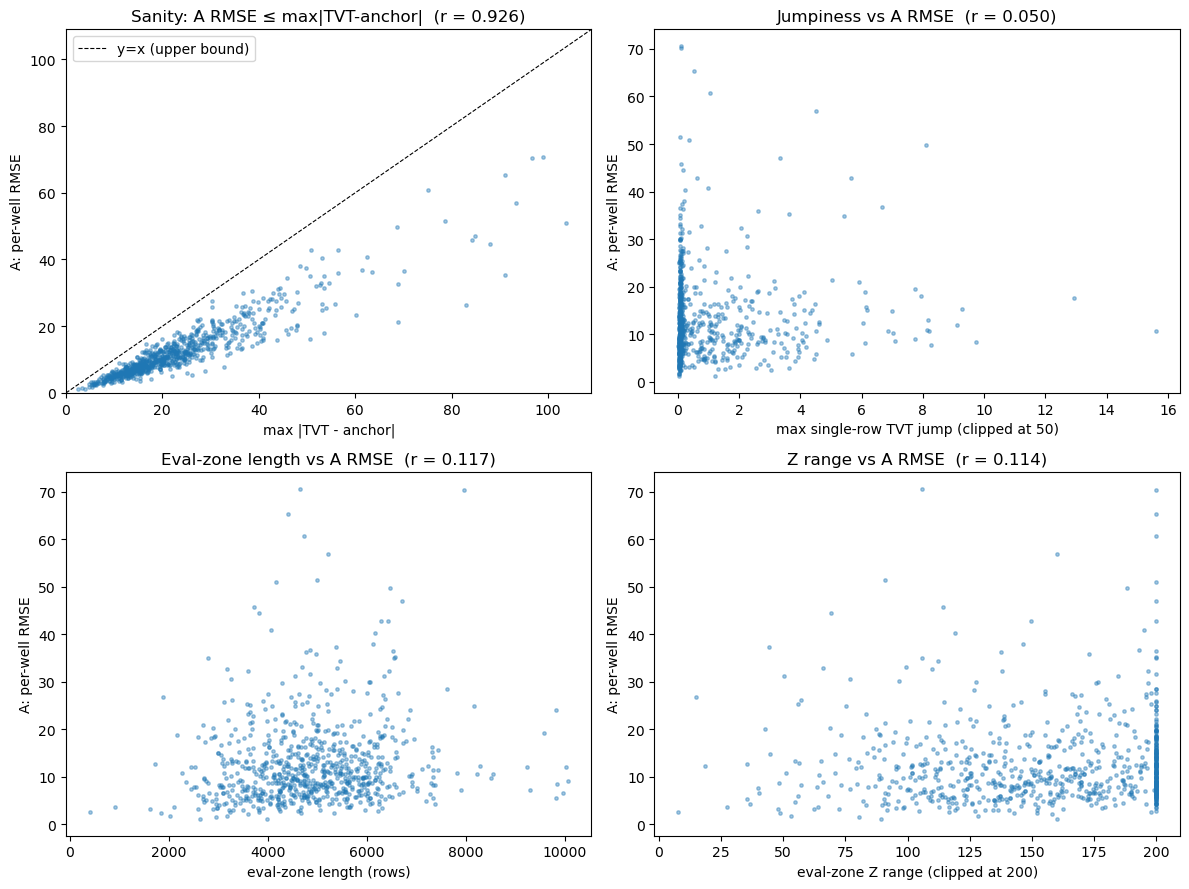

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (1) Max abs dev vs A RMSE — should be near-linear (mathematical bound)
ax = axes[0, 0]
ax.scatter(well_stats['tvt_max_abs_dev'], well_stats['a_rmse'], s=6, alpha=0.4)
lim = max(well_stats['tvt_max_abs_dev'].max(), well_stats['a_rmse'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='y=x (upper bound)')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('max |TVT - anchor|'); ax.set_ylabel('A: per-well RMSE')
rho = well_stats['tvt_max_abs_dev'].corr(well_stats['a_rmse'])
ax.set_title(f'Sanity: A RMSE ≤ max|TVT-anchor|  (r = {rho:.3f})')
ax.legend()

# (2) tvt_max_step (single-row jump) vs A RMSE — does jumpiness predict failure?
ax = axes[0, 1]
ax.scatter(well_stats['tvt_max_step'].clip(upper=50), well_stats['a_rmse'], s=6, alpha=0.4)
ax.set_xlabel('max single-row TVT jump (clipped at 50)'); ax.set_ylabel('A: per-well RMSE')
rho = well_stats['tvt_max_step'].corr(well_stats['a_rmse'])
ax.set_title(f'Jumpiness vs A RMSE  (r = {rho:.3f})')

# (3) Eval-zone length vs A RMSE
ax = axes[1, 0]
ax.scatter(well_stats['n_eval'], well_stats['a_rmse'], s=6, alpha=0.4)
ax.set_xlabel('eval-zone length (rows)'); ax.set_ylabel('A: per-well RMSE')
rho = well_stats['n_eval'].corr(well_stats['a_rmse'])
ax.set_title(f'Eval-zone length vs A RMSE  (r = {rho:.3f})')

# (4) Z range vs A RMSE — does wellbore wandering correlate with formation drift?
ax = axes[1, 1]
ax.scatter(well_stats['z_range'].clip(upper=200), well_stats['a_rmse'], s=6, alpha=0.4)
ax.set_xlabel('eval-zone Z range (clipped at 200)'); ax.set_ylabel('A: per-well RMSE')
rho = well_stats['z_range'].corr(well_stats['a_rmse'])
ax.set_title(f'Z range vs A RMSE  (r = {rho:.3f})')

plt.tight_layout(); plt.show()

Failure-mode examples:
  stable    283269ac  (A RMSE = 1.12, max_abs_dev = 2.49, max_step = 0.03)
  drifting  a783cc24  (A RMSE = 26.73, max_abs_dev = 55.78, max_step = 0.07)
  jumping   ccedb12b  (A RMSE = 10.61, max_abs_dev = 18.41, max_step = 15.61)


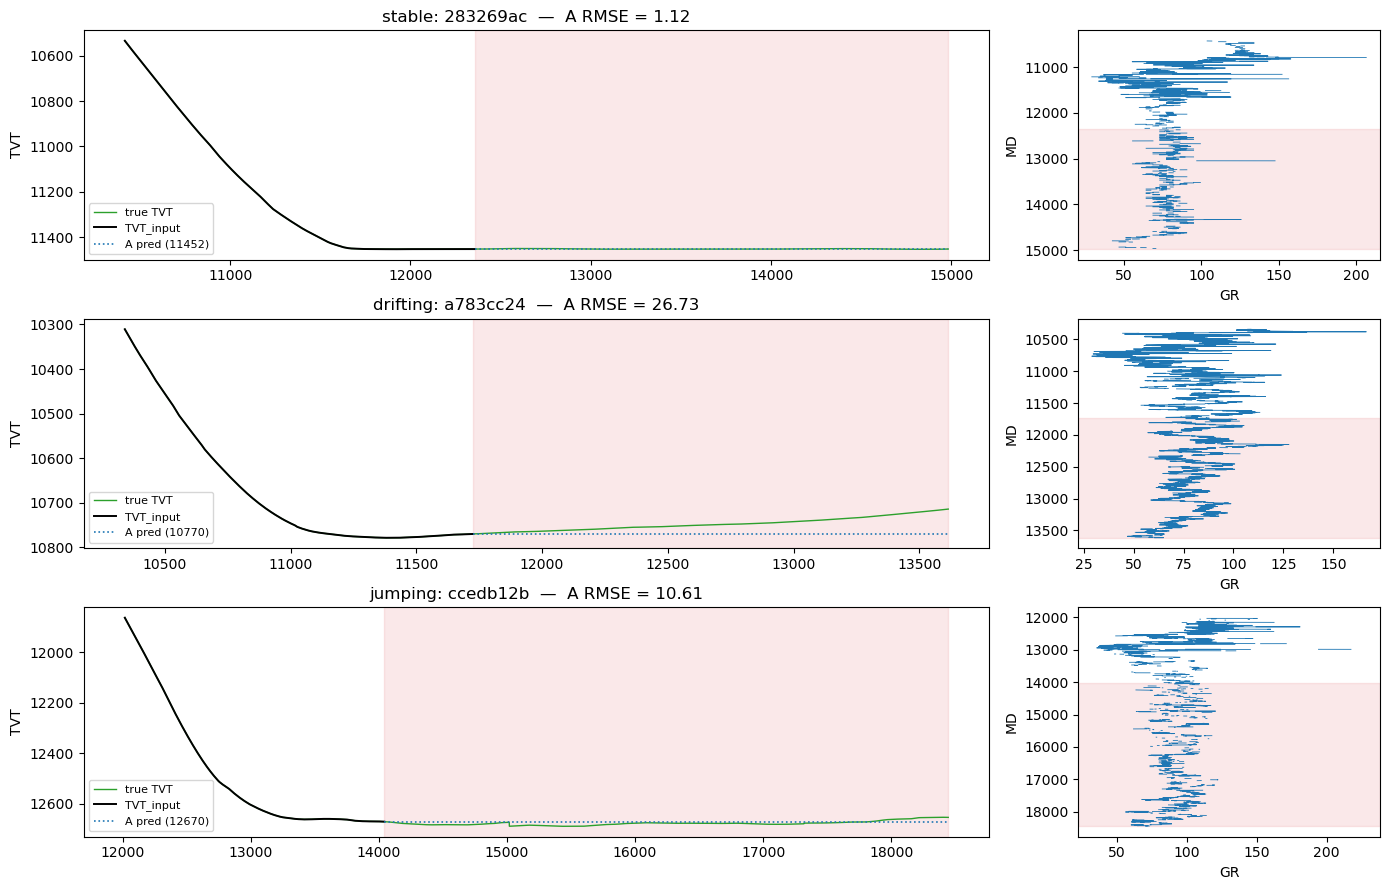

In [7]:
# Cluster failure modes: pick one from each of three regimes for visualization.
# (a) Stable: low max_abs_dev (A wins by default)
# (b) Drifting: high range, monotonic, low max_step (steady drift)
# (c) Jumping: high max_step (formation crossing)
stable   = well_stats[well_stats['tvt_max_abs_dev'] < 5].sort_values('a_rmse').head(1)
drifting = (well_stats[(well_stats['tvt_monotonic_inc'] | well_stats['tvt_monotonic_dec'])
                       & (~well_stats['tvt_monotonic_inc'] | ~well_stats['tvt_monotonic_dec'])
                       & (well_stats['tvt_max_step'] < 5)
                       & (well_stats['tvt_max_abs_dev'] > 30)]
            .sort_values('a_rmse', ascending=False).head(1))
jumping  = well_stats.sort_values('tvt_max_step', ascending=False).head(1)

examples = [('stable',   stable.index[0]   if len(stable)   else None),
            ('drifting', drifting.index[0] if len(drifting) else None),
            ('jumping',  jumping.index[0]  if len(jumping)  else None)]
examples = [(tag, w) for tag, w in examples if w is not None]
print('Failure-mode examples:')
for tag, w in examples:
    print(f'  {tag:8s}  {w}  (A RMSE = {well_stats.loc[w, "a_rmse"]:.2f}, '
          f'max_abs_dev = {well_stats.loc[w, "tvt_max_abs_dev"]:.2f}, '
          f'max_step = {well_stats.loc[w, "tvt_max_step"]:.2f})')

fig, axes = plt.subplots(len(examples), 2, figsize=(14, 3*len(examples)),
                         gridspec_kw={'width_ratios': [3, 1]}, squeeze=False)
for i, (tag, well) in enumerate(examples):
    g = train_df[train_df['well'] == well].reset_index(drop=True)
    eval_mask = g[COL_TVT_INPUT].isna().values
    eval_idx = np.where(eval_mask)[0]
    known_idx = np.where(~eval_mask)[0]
    anchor = g[COL_TVT_INPUT].iloc[known_idx[-1]]
    md_arr = g[COL_MD].values
    ax_t = axes[i, 0]
    ax_t.plot(md_arr, g[COL_TVT].values, color='C2', lw=1.0, label='true TVT')
    ax_t.plot(md_arr[~eval_mask], g[COL_TVT_INPUT].values[~eval_mask], color='k', lw=1.4, label='TVT_input')
    if eval_idx.size:
        ax_t.axvspan(md_arr[eval_idx[0]], md_arr[eval_idx[-1]], alpha=0.10, color='C3')
        ax_t.hlines(anchor, md_arr[eval_idx[0]], md_arr[eval_idx[-1]], color='C0', ls=':',
                    lw=1.2, label=f'A pred ({anchor:.0f})')
    ax_t.invert_yaxis()
    ax_t.set_title(f'{tag}: {well}  —  A RMSE = {well_stats.loc[well, "a_rmse"]:.2f}')
    ax_t.set_ylabel('TVT'); ax_t.legend(loc='best', fontsize=8)

    ax_g = axes[i, 1]
    ax_g.plot(g[COL_GR].values, md_arr, color='C0', lw=0.6)
    if eval_idx.size:
        ax_g.axhspan(md_arr[eval_idx[0]], md_arr[eval_idx[-1]], alpha=0.10, color='C3')
    ax_g.set_xlabel('GR'); ax_g.set_ylabel('MD'); ax_g.invert_yaxis()
plt.tight_layout(); plt.show()

## 4. Feature engineering scaffold

**The leakage rule.** A feature for an eval row is allowed to use:
- Anything from the well's *known* portion (where `TVT_input == TVT`)
- Anything from rows that don't depend on `TVT` (so `MD, X, Y, Z, GR` from any row, including the eval zone)
- The well's typewell (always available)

It is **not** allowed to use `TVT` of any eval row in the same well. Equivalently: if you mask out the `TVT`
column entirely, you must still be able to compute the feature.

**Feature set (~17 features), grouped:**
- *Geometry of current row:* `md, x, y, z` — observed in test.
- *GR of current row + local context:* `gr` (interpolated), `gr_local_mean_50, gr_local_std_50` (centered
  rolling window — fine because GR is observed everywhere in test).
- *Anchor-row state:* `anchor_tvt, anchor_z, anchor_md, anchor_gr` — captured at the boundary row.
- *Anchor variants:* `smooth_anchor_tvt_50` (mean of last 50 known TVT), `slope_tvt_md_50` (linear slope of
  last 50 known TVT-vs-MD).
- *Deltas from anchor:* `d_md_from_anchor, d_z_from_anchor, d_gr_from_anchor` (observed quantities only).
- *GR-template correlation:* `gr_match_tvt` (the predicted TVT from §1's `predict_gr_match_v2`),
  `gr_match_sim` (cosine similarity of the chosen match — confidence indicator),
  `gr_match_delta_anchor` (= gr_match_tvt − anchor_tvt).

Output: a DataFrame with one row per *eval row* of the well, a `well` column, a `row_idx` column (position
within its own well's CSV — needed for the submission later), and a `target_tvt` column when ground truth
is available (train only).

In [8]:
FEATURE_COLS = [
    'md', 'x', 'y', 'z', 'gr',
    'gr_local_mean_50', 'gr_local_std_50',
    'anchor_tvt', 'anchor_z', 'anchor_md', 'anchor_gr',
    'smooth_anchor_tvt_50', 'slope_tvt_md_50',
    'd_md_from_anchor', 'd_z_from_anchor', 'd_gr_from_anchor',
    'gr_match_tvt', 'gr_match_sim', 'gr_match_delta_anchor',
]

def featurize_well(g: pd.DataFrame, tw: pd.DataFrame, well_id: str | None = None) -> pd.DataFrame:
    """Compute features for the eval rows of one well. Returns DataFrame indexed 0..(n_eval-1)."""
    g = g.reset_index(drop=True)
    n = len(g)
    eval_mask = g[COL_TVT_INPUT].isna().values
    if not eval_mask.any():
        return pd.DataFrame(columns=['well', 'row_idx', *FEATURE_COLS])
    known_idx = np.where(~eval_mask)[0]
    if len(known_idx) == 0:
        return pd.DataFrame(columns=['well', 'row_idx', *FEATURE_COLS])
    anchor_idx = known_idx[-1]
    anchor_tvt = float(g[COL_TVT_INPUT].iloc[anchor_idx])
    anchor_z   = float(g[COL_Z].iloc[anchor_idx])
    anchor_md  = float(g[COL_MD].iloc[anchor_idx])
    gr_filled  = pd.Series(g[COL_GR].values).interpolate(limit_direction='both').fillna(0.0).values
    anchor_gr  = float(gr_filled[anchor_idx])

    K = 50
    last_K = known_idx[-K:] if len(known_idx) >= K else known_idx
    smooth_anchor = float(g[COL_TVT_INPUT].iloc[last_K].mean())
    if len(last_K) >= 2:
        slope, _ = np.polyfit(g[COL_MD].values[last_K], g[COL_TVT_INPUT].values[last_K], 1)
    else:
        slope = 0.0

    gr_series = pd.Series(gr_filled)
    gr_local_mean = gr_series.rolling(50, center=True, min_periods=1).mean().values
    gr_local_std  = gr_series.rolling(50, center=True, min_periods=1).std().fillna(0.0).values

    gr_match_pred, gr_match_sim = predict_gr_match_v2(g, tw)

    feats_full = pd.DataFrame({
        'md':                   g[COL_MD].values,
        'x':                    g[COL_X].values,
        'y':                    g[COL_Y].values,
        'z':                    g[COL_Z].values,
        'gr':                   gr_filled,
        'gr_local_mean_50':     gr_local_mean,
        'gr_local_std_50':      gr_local_std,
        'anchor_tvt':           anchor_tvt,
        'anchor_z':             anchor_z,
        'anchor_md':            anchor_md,
        'anchor_gr':            anchor_gr,
        'smooth_anchor_tvt_50': smooth_anchor,
        'slope_tvt_md_50':      float(slope),
        'd_md_from_anchor':     g[COL_MD].values - anchor_md,
        'd_z_from_anchor':      g[COL_Z].values  - anchor_z,
        'd_gr_from_anchor':     gr_filled        - anchor_gr,
        'gr_match_tvt':         gr_match_pred,
        'gr_match_sim':         gr_match_sim,
        'gr_match_delta_anchor': gr_match_pred - anchor_tvt,
    })
    feats_full['well']    = well_id if well_id is not None else (g['well'].iloc[0] if 'well' in g.columns else None)
    feats_full['row_idx'] = np.arange(n, dtype=np.int32)

    out = feats_full.loc[eval_mask].reset_index(drop=True)
    if COL_TVT in g.columns:
        out['target_tvt'] = g[COL_TVT].values[eval_mask]
    return out[['well', 'row_idx', *FEATURE_COLS] + (['target_tvt'] if 'target_tvt' in out.columns else [])]

# Smoke test on one well
_w = train_df['well'].iloc[0]
_g = train_df[train_df['well'] == _w]
_tw = train_tw[_w]
_f = featurize_well(_g, _tw, _w)
print(f'Sample featurization for well {_w}: shape {_f.shape}')
_f.head()

Sample featurization for well 000d7d20: shape (3836, 22)


,well,row_idx,md,x,y,z,gr,gr_local_mean_50,gr_local_std_50,anchor_tvt,anchor_z,anchor_md,anchor_gr,smooth_anchor_tvt_50,slope_tvt_md_50,d_md_from_anchor,d_z_from_anchor,d_gr_from_anchor,gr_match_tvt,gr_match_sim,gr_match_delta_anchor,target_tvt
0,000d7d20,1442,12909.0,2983537.06,1070212.72,-9735.07,105.434871,103.507671,4.636220,11747.37,-9735.08,12908.0,105.640426,11747.0144,0.016695,1.0,0.01,-0.205555,11716.5,0.605656,-30.87,11747.38
1,000d7d20,1443,12910.0,2983537.03,1070213.72,-9735.06,105.229316,103.096959,4.650725,11747.37,-9735.08,12908.0,105.640426,11747.0144,0.016695,2.0,0.02,-0.411111,11716.0,0.620455,-31.37,11747.39
2,000d7d20,1444,12911.0,2983537.00,1070214.72,-9735.05,105.023760,102.670028,4.708965,11747.37,-9735.08,12908.0,105.640426,11747.0144,0.016695,3.0,0.03,-0.616666,11713.0,0.635555,-34.37,11747.40
3,000d7d20,1445,12912.0,2983536.97,1070215.71,-9735.04,104.818205,102.226879,4.811026,11747.37,-9735.08,12908.0,105.640426,11747.0144,0.016695,4.0,0.04,-0.822222,11710.0,0.605923,-37.37,11747.40
4,000d7d20,1446,12913.0,2983536.94,1070216.71,-9735.03,103.960888,101.767512,4.955663,11747.37,-9735.08,12908.0,105.640426,11747.0144,0.016695,5.0,0.05,-1.679538,11709.5,0.573528,-37.87,11747.41


In [9]:
# Featurize all 773 train wells. ~30-90s. Cache the result.
TRAIN_FEAT_CACHE = CACHE_DIR / 'train_features.pkl'

def featurize_all_train(force_reload: bool = False) -> pd.DataFrame:
    if TRAIN_FEAT_CACHE.exists() and not force_reload:
        df = pd.read_pickle(TRAIN_FEAT_CACHE)
        print(f'Loaded train-feature cache: {df.shape}')
        return df
    print('Featurizing 773 train wells...')
    rows = []
    for i, (well, g) in enumerate(train_df.groupby('well', sort=False)):
        if i and i % 100 == 0: print(f'  ... {i} wells', flush=True)
        rows.append(featurize_well(g, train_tw.get(well), well))
    out = pd.concat(rows, ignore_index=True)
    # Downcast floats to save memory (~halves footprint)
    for c in out.columns:
        if out[c].dtype == 'float64': out[c] = out[c].astype('float32')
    out.to_pickle(TRAIN_FEAT_CACHE)
    print(f'Cached: {out.shape} -> {TRAIN_FEAT_CACHE.name}')
    return out

train_feats = featurize_all_train()
print(f'\nMemory: ~{train_feats.memory_usage(deep=True).sum() / 1e6:.0f} MB')
print(f'Wells: {train_feats["well"].nunique()}  |  rows: {len(train_feats):,}')
train_feats.head()

Featurizing 773 train wells...
  ... 100 wells
  ... 200 wells
  ... 300 wells
  ... 400 wells
  ... 500 wells
  ... 600 wells
  ... 700 wells
Cached: (3783989, 22) -> train_features.pkl

Memory: ~379 MB
Wells: 773  |  rows: 3,783,989


,well,row_idx,md,x,y,z,gr,gr_local_mean_50,gr_local_std_50,anchor_tvt,anchor_z,anchor_md,anchor_gr,smooth_anchor_tvt_50,slope_tvt_md_50,d_md_from_anchor,d_z_from_anchor,d_gr_from_anchor,gr_match_tvt,gr_match_sim,gr_match_delta_anchor,target_tvt
0,000d7d20,1442,12909.0,2983537.0,1070212.75,-9735.070312,105.434868,103.507668,4.636220,11747.370117,-9735.080078,12908.0,105.640427,11747.014648,0.016695,1.0,0.01,-0.205555,11716.5,0.605656,-30.870001,11747.379883
1,000d7d20,1443,12910.0,2983537.0,1070213.75,-9735.059570,105.229317,103.096962,4.650725,11747.370117,-9735.080078,12908.0,105.640427,11747.014648,0.016695,2.0,0.02,-0.411111,11716.0,0.620455,-31.370001,11747.389648
2,000d7d20,1444,12911.0,2983537.0,1070214.75,-9735.049805,105.023758,102.670029,4.708965,11747.370117,-9735.080078,12908.0,105.640427,11747.014648,0.016695,3.0,0.03,-0.616666,11713.0,0.635555,-34.369999,11747.400391
3,000d7d20,1445,12912.0,2983537.0,1070215.75,-9735.040039,104.818207,102.226883,4.811026,11747.370117,-9735.080078,12908.0,105.640427,11747.014648,0.016695,4.0,0.04,-0.822222,11710.0,0.605923,-37.369999,11747.400391
4,000d7d20,1446,12913.0,2983537.0,1070216.75,-9735.030273,103.960892,101.767509,4.955663,11747.370117,-9735.080078,12908.0,105.640427,11747.014648,0.016695,5.0,0.05,-1.679538,11709.5,0.573528,-37.869999,11747.410156


## 5. GroupKFold cross-validation scaffold

**Why grouped CV.** With non-grouped k-fold, eval rows from the same well end up in both train and val
folds. A model trained on those train rows would have seen the well's GR pattern, surface predictions, and
trajectory at training time, then "validate" on a held-out segment of the same well — that's a leaky
validation. Real test performance is on *new* wells the model has never seen.

`GroupKFold(n_splits=5)` with `groups=well` puts entire wells in either train or val, never both.
5 folds × ~155 val wells per fold ≈ 773. Each fold's pooled RMSE on its 155 val wells is an honest
estimate of out-of-well generalization.

In [10]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

groups = train_feats['well'].values
fold_assignments = np.full(len(train_feats), -1, dtype=np.int8)

splits = list(gkf.split(train_feats, groups=groups))
for fold, (tr_idx, va_idx) in enumerate(splits):
    fold_assignments[va_idx] = fold
    tr_wells = train_feats.iloc[tr_idx]['well'].nunique()
    va_wells = train_feats.iloc[va_idx]['well'].nunique()
    overlap = set(train_feats.iloc[tr_idx]['well']) & set(train_feats.iloc[va_idx]['well'])
    assert not overlap, f'fold {fold} has well overlap: {overlap}'
    print(f'fold {fold}: train wells={tr_wells:3d}  val wells={va_wells:3d}  '
          f'train rows={len(tr_idx):>9,}  val rows={len(va_idx):>9,}')

train_feats['fold'] = fold_assignments
assert (train_feats['fold'] >= 0).all(), 'some rows not assigned to any fold'
print(f'\nAll {len(train_feats):,} rows assigned to a fold. Folds attached as train_feats["fold"].')

fold 0: train wells=618  val wells=155  train rows=3,026,251  val rows=  757,738
fold 1: train wells=618  val wells=155  train rows=3,027,339  val rows=  756,650
fold 2: train wells=619  val wells=154  train rows=3,027,734  val rows=  756,255
fold 3: train wells=618  val wells=155  train rows=3,026,888  val rows=  757,101
fold 4: train wells=619  val wells=154  train rows=3,027,744  val rows=  756,245

All 3,783,989 rows assigned to a fold. Folds attached as train_feats["fold"].


## 6. Leakage sanity check

Three assertions, each guarding a specific failure mode:
1. **No feature equals the target.** If any feature column has zero variance vs `target_tvt` (i.e. exactly
   tracks it), it's leaking.
2. **Anchor consistency.** Within each well, `anchor_tvt` should be constant across all eval rows (it's a
   single value computed at the boundary), and equal to `TVT_input` at the well's last known row.
3. **Fold disjointness.** Already checked in §5 but re-asserted: no well appears in both train and val of
   any fold.

In [11]:
# (1) No feature is identical to target_tvt — within float32 tolerance
for c in FEATURE_COLS:
    diff = (train_feats[c].astype('float64') - train_feats['target_tvt'].astype('float64')).abs()
    assert (diff > 1e-3).any(), f'feature {c} appears identical to target_tvt — possible leakage'
print(f'(1) OK: none of the {len(FEATURE_COLS)} features equal target_tvt')

# (2) anchor_tvt is constant within each well, and equals TVT_input at last known row
n_violations = 0
for well, group in train_feats.groupby('well'):
    if group['anchor_tvt'].nunique() > 1:
        n_violations += 1; continue
    a_feat = float(group['anchor_tvt'].iloc[0])
    g = train_df[train_df['well'] == well]
    eval_mask = g[COL_TVT_INPUT].isna().values
    known_idx = np.where(~eval_mask)[0]
    a_truth = float(g[COL_TVT_INPUT].iloc[known_idx[-1]])
    if abs(a_feat - a_truth) > 1e-3:
        n_violations += 1
assert n_violations == 0, f'{n_violations} wells have inconsistent anchor_tvt'
print(f'(2) OK: anchor_tvt is consistent across all 773 wells')

# (3) Fold disjointness on wells
for fold in range(N_SPLITS):
    val_wells = set(train_feats[train_feats['fold'] == fold]['well'])
    tr_wells  = set(train_feats[train_feats['fold'] != fold]['well'])
    assert not (val_wells & tr_wells), f'fold {fold} has well overlap'
print(f'(3) OK: all {N_SPLITS} folds are well-disjoint')

(1) OK: none of the 19 features equal target_tvt
(2) OK: anchor_tvt is consistent across all 773 wells
(3) OK: all 5 folds are well-disjoint


## 7. Featurize test wells and save everything

Apply the same `featurize_well` to the 3 test wells and save. Test features won't have a `target_tvt`
column (no labels available).

In [12]:
TEST_FEAT_CACHE = CACHE_DIR / 'test_features.pkl'

test_rows = []
for f in sorted(TEST_DIR.glob('*__horizontal_well.csv')):
    well = f.name.replace('__horizontal_well.csv', '')
    g = pd.read_csv(f); g['well'] = well
    tw_path = TEST_DIR / f'{well}__typewell.csv'
    tw = pd.read_csv(tw_path) if tw_path.exists() else None
    test_rows.append(featurize_well(g, tw, well))
test_feats = pd.concat(test_rows, ignore_index=True)
for c in test_feats.columns:
    if test_feats[c].dtype == 'float64': test_feats[c] = test_feats[c].astype('float32')
test_feats.to_pickle(TEST_FEAT_CACHE)

print(f'Test featurized: {test_feats.shape} -> {TEST_FEAT_CACHE.name}')
print(f'Wells: {sorted(test_feats["well"].unique())}')
test_feats.head()

Test featurized: (14151, 21) -> test_features.pkl
Wells: ['000d7d20', '00bbac68', '00e12e8b']


,well,row_idx,md,x,y,z,gr,gr_local_mean_50,gr_local_std_50,anchor_tvt,anchor_z,anchor_md,anchor_gr,smooth_anchor_tvt_50,slope_tvt_md_50,d_md_from_anchor,d_z_from_anchor,d_gr_from_anchor,gr_match_tvt,gr_match_sim,gr_match_delta_anchor
0,000d7d20,1442,12909.0,2983537.0,1070212.75,-9735.070312,105.434868,103.507668,4.636220,11747.370117,-9735.080078,12908.0,105.640427,11747.014648,0.016695,1.0,0.01,-0.205555,11716.5,0.605656,-30.870001
1,000d7d20,1443,12910.0,2983537.0,1070213.75,-9735.059570,105.229317,103.096962,4.650725,11747.370117,-9735.080078,12908.0,105.640427,11747.014648,0.016695,2.0,0.02,-0.411111,11716.0,0.620455,-31.370001
2,000d7d20,1444,12911.0,2983537.0,1070214.75,-9735.049805,105.023758,102.670029,4.708965,11747.370117,-9735.080078,12908.0,105.640427,11747.014648,0.016695,3.0,0.03,-0.616666,11713.0,0.635555,-34.369999
3,000d7d20,1445,12912.0,2983537.0,1070215.75,-9735.040039,104.818207,102.226883,4.811026,11747.370117,-9735.080078,12908.0,105.640427,11747.014648,0.016695,4.0,0.04,-0.822222,11710.0,0.605923,-37.369999
4,000d7d20,1446,12913.0,2983537.0,1070216.75,-9735.030273,103.960892,101.767509,4.955663,11747.370117,-9735.080078,12908.0,105.640427,11747.014648,0.016695,5.0,0.05,-1.679538,11709.5,0.573528,-37.869999


In [13]:
# Cross-check that test feature row count matches sample_submission row count
ss = pd.read_csv(DATA / 'sample_submission.csv')
print(f'sample_submission rows: {len(ss):,}')
print(f'test_feats rows:        {len(test_feats):,}')
if len(ss) == len(test_feats):
    print('Match — every sample_submission row has a feature row.')
else:
    print('MISMATCH — investigate before notebook 05 trains anything.')
    # Show which row_ids are in one but not the other
    test_ids = test_feats['well'].astype(str) + '_' + test_feats['row_idx'].astype(str)
    in_ss_not_feats = set(ss[ss.columns[0]]) - set(test_ids)
    in_feats_not_ss = set(test_ids) - set(ss[ss.columns[0]])
    print(f'  in sample_submission but not test_feats: {len(in_ss_not_feats)}')
    print(f'  in test_feats but not sample_submission: {len(in_feats_not_ss)}')

sample_submission rows: 14,151
test_feats rows:        14,151
Match — every sample_submission row has a feature row.


## 8. Findings + roadmap to notebook 05

*Fill in after running.*

**Target audit (§2).**
- Median max|TVT − anchor| = ___ (i.e., A's per-well RMSE has a median ceiling around this).
- Fraction of wells with max|TVT − anchor| ≤ 5: ___%. (A is essentially perfect on these — any model has
  to lose nothing here.)
- Fraction of wells with max|TVT − anchor| > 30: ___%. (The wells where there's room to win.)
- Monotonicity: ___% strictly monotonic, ___% non-monotonic. Strictly-monotonic eval zones suggest steady
  formation drift; non-monotonic suggests crossings + returns.

**Error audit (§3).**
- Strongest correlate of A's RMSE: ___ (r = ___).
- The three failure-mode visualizations (stable / drifting / jumping) suggest the dominant failure mode is ___.

**Feature scaffold (§4).**
- 19 feature columns + `well` + `row_idx` + `target_tvt`. Cached at `cache/train_features.pkl` (~___ MB).
- Test features cached at `cache/test_features.pkl` (___ rows, matches sample_submission: yes/no).

**CV scaffold (§5).**
- 5-fold GroupKFold by well. Roughly ___ val wells per fold, ___ val rows per fold.
- Fold assignments stored on `train_feats['fold']`.

**Leakage check (§6).** All three assertions pass.

**Notebook 05 plan: first XGBoost with proper CV.**
1. Load `train_features.pkl`, train an XGBoost regressor with the 19 features, target = `target_tvt`.
2. CV: for each fold, train on the 4 train folds, predict on val fold's eval rows, accumulate predictions.
3. Pooled RMSE across all val predictions = honest CV estimate. Compare directly to A's 15.91.
4. Feature-importance plot — does the model actually use anything beyond `anchor_tvt`?
5. If CV RMSE < 15.91: train final model on all train data, predict on test_feats, write submission.
6. If CV RMSE ≈ 15.91: report which features didn't help and why, iterate.

**What the model needs to learn that A can't.** A predicts `target_tvt = anchor_tvt`. The features the
model has access to that A doesn't are: `gr_match_tvt`, `gr_match_sim`, `gr_match_delta_anchor`,
`d_md/z/gr_from_anchor`, `gr_local_*_50`, `slope_tvt_md_50`. The hope is that *some combination* of these
tells the model when to deviate from `anchor_tvt` — and by how much. A boosted tree should be able to learn
rules like "when `gr_match_sim` > 0.8 AND |gr_match_delta_anchor| > 20 AND `d_md_from_anchor` > 1000,
shift the prediction toward `gr_match_tvt`" — exactly the kind of conditional logic hand-crafted methods
couldn't express.